# 4-Lobe Lightbridge Fuel

## Burnable Absorber Displacer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import kaist
from ttnte.cad.curves import qtrlobe
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig
from ttnte.cad import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = kaist()

In [3]:
D = 1.26 # Fuel width
D2 = D*0.5
X = 1.36 # Channel pitch
delta = 0.306 # Width of lobes
y2 = delta * 0.5
d = 0.04 # Thickness of cladding at valleys
dmax = 0.102 # Thickness of cladding at ends of the lobes
R = 0.297 # Radius defining outer curve of valleys
a = 0.156 # Displacer width

y1 = y2-d # Half of width of inner lobe
x1 = (D2 - R - y2 - dmax) # Portrusion of innerlobe
x2 = x1 + dmax # Portrusion of outer lobe

In [4]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
burn = cad.line(p1=(a / (2 ** 0.5), 0), p0=(0, a / (2 ** 0.5)))
fuel = qtrlobe(outrad=R + d, portrs=x1, hfwidth=y1 )
clad = qtrlobe(outrad=R, portrs=x2, hfwidth=y2 )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [5]:
# Create IGA mesh object
mesh = IGAMesh()

# Create NURBS surfaces and add them
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    osec = origin.slice(0, sections[i], sections[i + 1])
    bsec = burn.slice(0, sections[i], sections[i + 1])
    fsec = fuel.slice(0, sections[i], sections[i + 1])
    csec = clad.slice(0, sections[i], sections[i + 1])

    # Create patches
    mesh.add_patch(Patch(cad.ruled(osec, bsec), "BA (UO2 FA)"))
    mesh.add_patch(Patch(cad.ruled(bsec, fsec), "UO2 3%"))
    mesh.add_patch(Patch(cad.ruled(fsec, csec), "Guide Tube"))
    mesh.add_patch(Patch(cad.ruled(csec, edges[i]), "Water"))
    
# Refine mesh
mesh.refine(7, 2)
    
# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=12, reflective_boundaries=True)
  -> Patch(material=BA (UO2 FA), source=None, id=0, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=1, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=2, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=3, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=BA (UO2 FA), source=None, id=4, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=5, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=6, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=7, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=BA (UO2 FA), source=None, id=8, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=UO2 3%, source=None, id=9, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Guide Tube, source=None, id=10, name=None, shape=(5, 5), backend=geomdl)
  -> Patch(material=Water, source=None, id=11, name=None, shape=(5, 5), backend=geomdl)

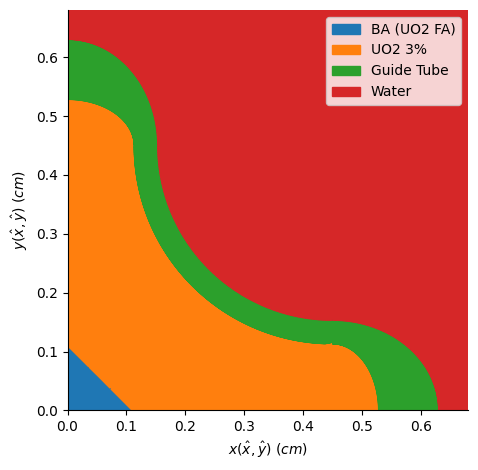

In [6]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.tight_layout()
plt.savefig("./figs/four_lobe_ba.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [7]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info_ba.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=4,
)
tts = assembler.build(use_tt=False, eps=1e-10)

# Save TT information
assembler.save_info("./tt_info_ba.csv")

Running MatrixAssembler.build()
Discretization: N = 16, G = 7, P = 12, A = 5, B = 5
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 3.02 s)
Step            Ranks                     Compression
H               33600,33600                   775.62
S               2,2100,2100                    13.48
F               2100,2100                      32.32
B_out           33600,33600                  7776.65
B_in            33600,33600                  7593.22
Running TTAssembler.build()
Discretization: N = 16, G = 7, P = 12, A = 5, B = 5
Operators: H, S, F, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/12 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 20.44 s)
Step            Ranks                     Compression
H               3,3,3,6,24,14               37029.65
S               3,3,2,4,10,7               137930.36
F               1,1,1,2,4,6                557786.56
B_out           4,6,10,10,22,3              29168.32
B_in            8,10,14,14,25,4             17747.59


...

ORx_in          4,45,19,36,18,6,2              14.95       32.63
ORy_in          4,16,2,2,6,6,3                184.01       32.63
ORJx_det_in     4,45,19,36,18,6,2              14.95       32.67
ORJy_det_in     4,16,2,2,6,6,3                184.01       32.67


Intg_bound_in   3,8,27,21,3                137518.16       33.11
H_bound_in      6,25,21,21,21,3           1181048.52       33.21
B_in            6,25,21,21,21,3           115566268.32       33.21
Jx_det_out      2,3                             0.73       33.22
Jy_det_out      1,1                             3.27       33.22
Rx_out          2,9,6,2                         1.03       33.25
Ry_out          2,6,6,3                         1.31       33.25


Ox_out          4,16,2,1,1                     23.56       33.37
Oy_out          4,16,2,1,1                     23.56       33.37
ORx_out         4,45,19,36,18,6,2              14.95       33.41
ORy_out         4,16,2,2,6,6,3                184.01       33.41
ORJx_det_out    4,45,19,36,18,6,2              14.95       33.45
ORJy_det_out    4,16,2,2,6,6,3                184.01       33.45


Intg_bound_out  4,24,21,3                     303.06       33.85
H_bound_out     4,24,21,21,21,3             15856.77       33.87
B_out           4,24,21,21,21,3             15856.77       33.87



Final Operators
H               3,3,3,6,24,34             375651253.69       34.93
S               3,3,2,4,10,22             1187139189.93       34.93
F               1,1,1,2,4,19              3856616090.68       34.93
B_in            8,38,101,101,43,4         13794035.57       34.93
B_out           4,34,97,97,40,3           15893262.72       34.93


## Solve

In [9]:
k, psi = eig(
    LHS=LinearOperator([tts.H, mats.B_out - mats.B_in, -tts.S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([tts.F], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 75,
        "threshold": 1e-10,
        "resets": 20,
    },
)

# Save solution
mesh.save(path="mesh_ba.hdf5", solution=psi, k=k)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

Starting power iteration
-- (0): k = 0.83262322, Angular Flux L2-Error = 3.57081296, Elapsed Time = 40.628
-- (1): k = 0.83361153, Angular Flux L2-Error = 0.00427195, Elapsed Time = 79.931
-- (2): k = 0.8336069, Angular Flux L2-Error = 3.288e-05, Elapsed Time = 118.346
-- (3): k = 0.83360686, Angular Flux L2-Error = 2.4e-07, Elapsed Time = 157.071
-- (4): k = 0.83360686, Angular Flux L2-Error = 0.0, Elapsed Time = 165.783
-- Converged: k = 0.83360686, Elapsed Time = 165.784


-- (1): k = 0.8311274, Angular Flux L2-Error = 0.0842954, Elapsed Time = 2843.89


-- (2): k = 0.83862407, Angular Flux L2-Error = 0.00746854, Elapsed Time = 4266.815


-- (3): k = 0.83901829, Angular Flux L2-Error = 0.00278534, Elapsed Time = 5689.678


-- (4): k = 0.83904807, Angular Flux L2-Error = 0.00157574, Elapsed Time = 7112.629


...

-- (41): k = 0.83905382, Angular Flux L2-Error = 2e-08, Elapsed Time = 59760.402


-- (42): k = 0.83905382, Angular Flux L2-Error = 2e-08, Elapsed Time = 61183.636


-- (43): k = 0.83905382, Angular Flux L2-Error = 1e-08, Elapsed Time = 62606.771


-- (44): k = 0.83905382, Angular Flux L2-Error = 1e-08, Elapsed Time = 64030.386


-- (45): k = 0.83905382, Angular Flux L2-Error = 1e-08, Elapsed Time = 65453.752
-- Converged: k = 0.83905382, Elapsed Time = 65453.752


## Plot and Compare to OpenMC

<Figure size 640x480 with 0 Axes>

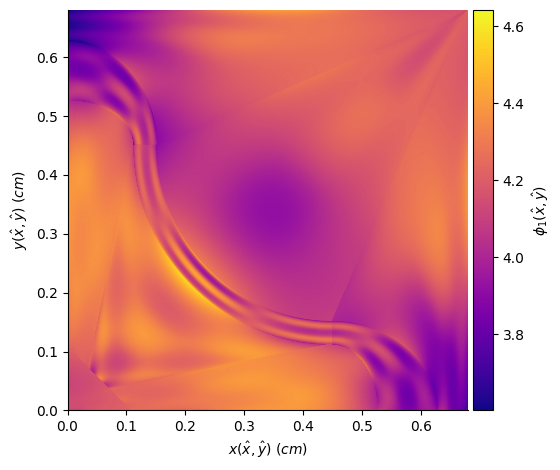

<Figure size 640x480 with 0 Axes>

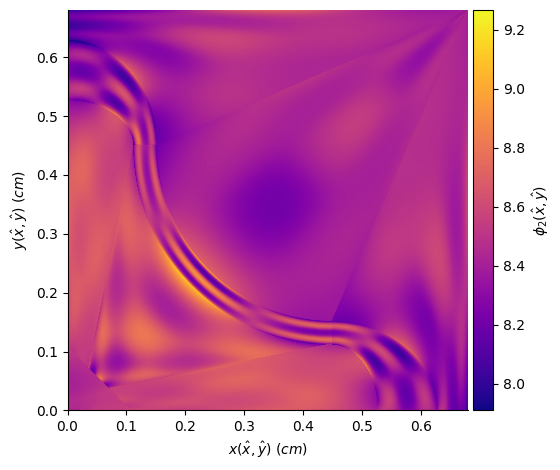

<Figure size 640x480 with 0 Axes>

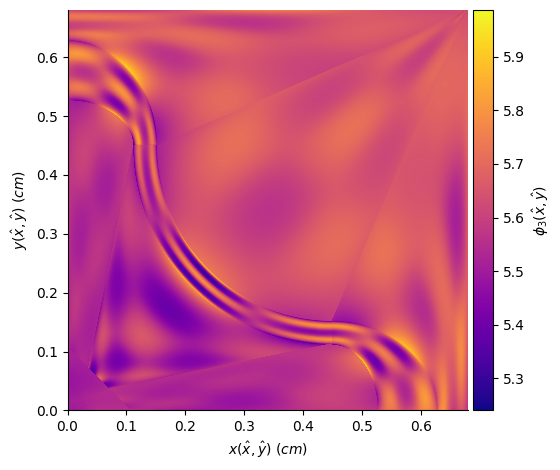

<Figure size 640x480 with 0 Axes>

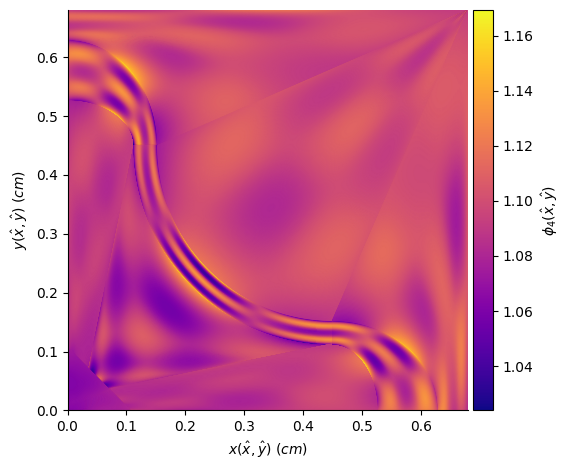

<Figure size 640x480 with 0 Axes>

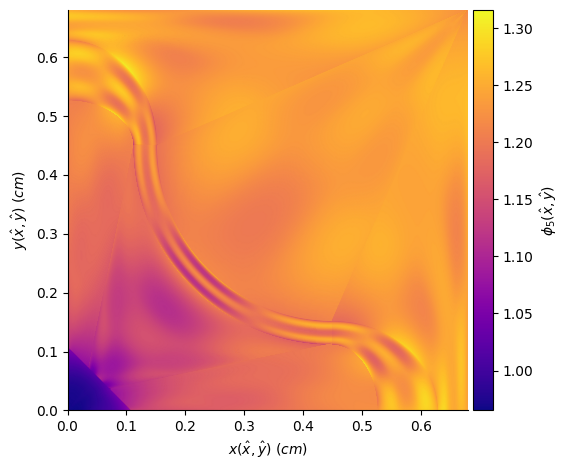

<Figure size 640x480 with 0 Axes>

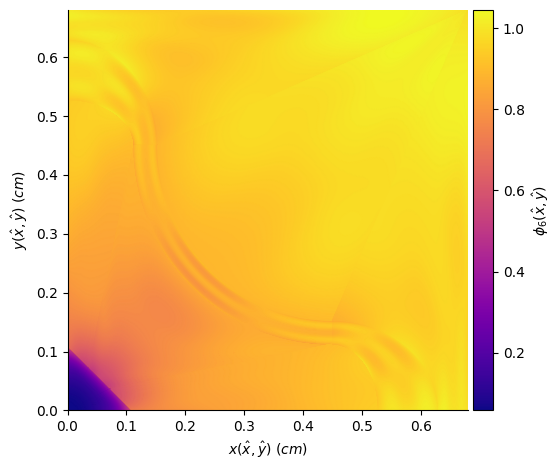

<Figure size 640x480 with 0 Axes>

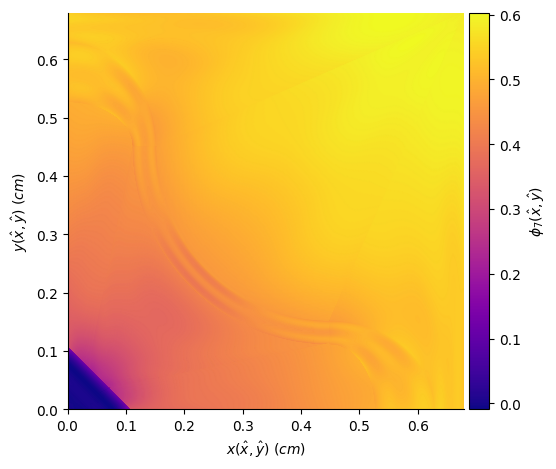

In [11]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(5, 5))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax, cbar = mesh.plot(plot_ctrlpts=False)
    cbar.set_label(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi_{g + 1}_ba.png", dpi=300)
    plt.show()

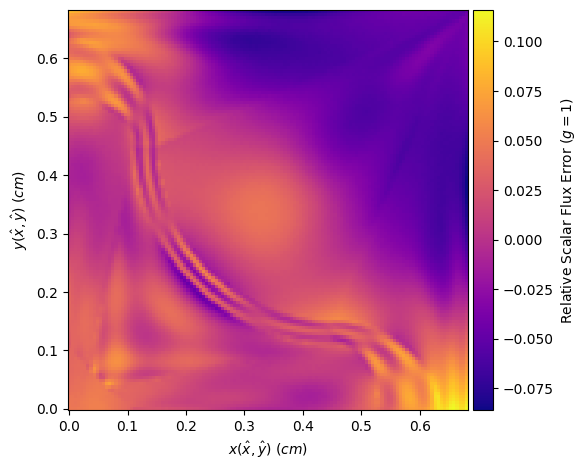

Scalar flux Relative L2-error (g = 1): 0.036156366335636556


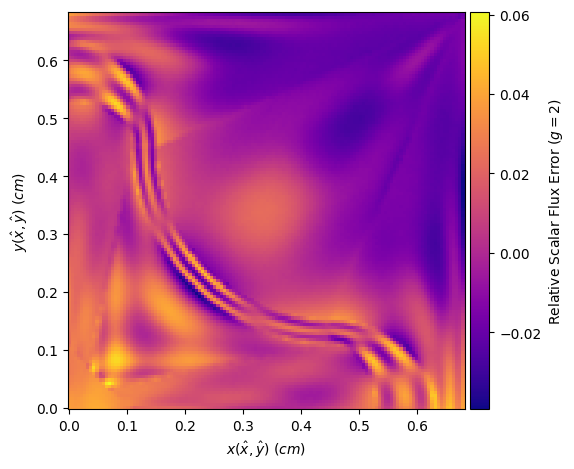

Scalar flux Relative L2-error (g = 2): 0.017394018479832855


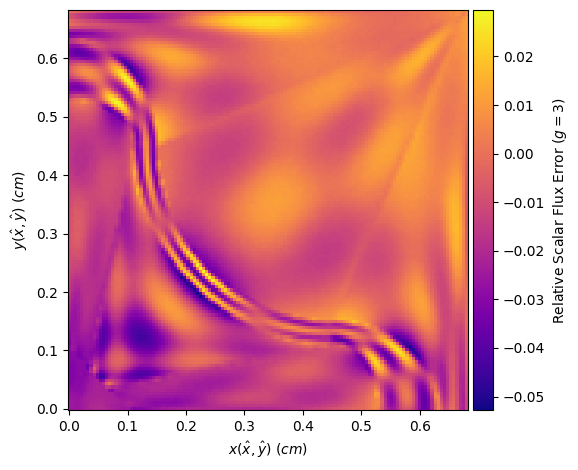

Scalar flux Relative L2-error (g = 3): 0.01355761023202711


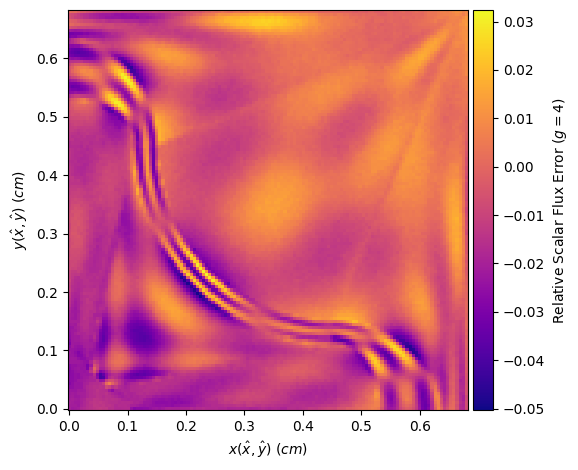

Scalar flux Relative L2-error (g = 4): 0.012210205091452231


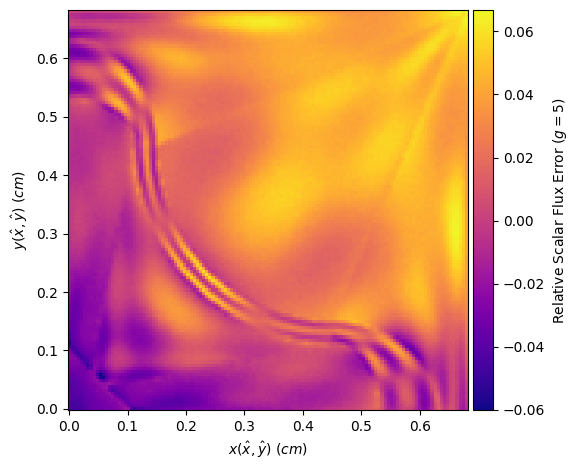

Scalar flux Relative L2-error (g = 5): 0.03217198780183383


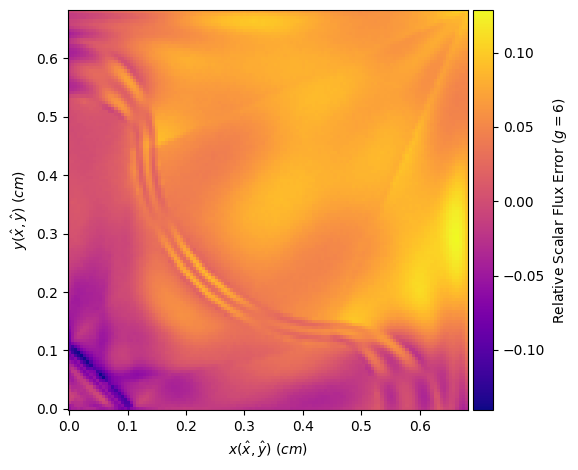

Scalar flux Relative L2-error (g = 6): 0.06189727725127562


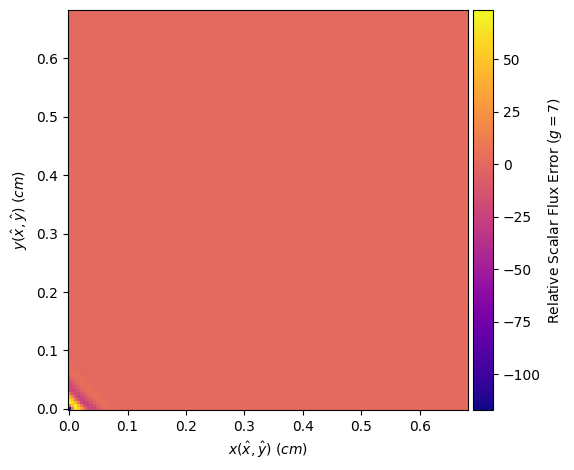

Scalar flux Relative L2-error (g = 7): 0.06906823664590009
Total scalar flux Relative L2-error: 0.02138859149020721


In [12]:
# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

# Regular mesh
X, Y = np.meshgrid(
    np.linspace(0, X / 2, phi_mc.shape[1]),
    np.linspace(0, X / 2, phi_mc.shape[2]),
)

for g in range(xs_server.num_groups):    
    # Plot relative error
    plt.clf()
    ax = plt.gca()
    cmesh = ax.pcolormesh(
        X, Y, (phi_mc[g,] - phi_avg[g,]) / phi_mc[g,], cmap="plasma"
    )
    divider = make_axes_locatable(ax)

    plt.colorbar(
        cmesh,
        cax=divider.append_axes("right", size="5%", pad=0.05),
        label=f"Relative Scalar Flux Error ($g = {g + 1}$)",
    )
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x(\hat{x}, \hat{y})~(cm)$")
    ax.set_ylabel(r"$y(\hat{x}, \hat{y})~(cm)$")
    plt.tight_layout()
    plt.savefig(f"./figs/phi{g + 1}_ba_error.png", dpi=300)
    plt.show()
    
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)